# Traffic Model

## Release AIM

lfc/maveric issues #2. **Create Non-Trivial and Interesting Dummy Trac Model to Demonstrate the Benet of Energy Savings**

## objectives

0. questions
1. function: bdt_traffic_load()
2. traffic load model
3. traffic load optimizer (TLO) metric
4. x_app for energy savings


## obj 1: function: bdt_traffic_load()

Write a function that takes relevant input parameters to generate realistic trac data for the following eight scenarios:

Scenarios:

- Annual: 
    - 2020 vs 2024 Comparison
- Monthly (Seasonal):
    - O-Season/Vacation vs Normal Trac Patterns
    - Other Seasonal Examples
Weekly- :
    - Weekdays vs Weekends
    - Other Weekly Patterns
- Daily:
    - Day vs Night
    - Other Daily Variations

### city story

> come up with a city story and write digital model of that city.

**Hell's Kitchen** (oh yes daredevil fan) is a small, eco-friendly city designed with sustainability and efficiency in mind. It has a population of ~100,000 and is divided into distinct areas:

- Office & Business Hub
    - Two office areas (Downtown Core & Wall Street) house corporate offices, government buildings, and co-working spaces.
    - High public transit usage during peak hours.

- Residential Zones
    - Two neighborhoods: North Greenfield (high-rise apartments) and Westwood Villas (suburban homes).
    - Traffic varies by time (morning rush, evening return, weekend outings).

- Transportation Hubs
    - Central Station (train & bus) near Downtown.
    - Multiple bus routes and bike lanes.

- Entertainment District
    - Shopping malls, movie theaters, and a concert arena.
    - Peak traffic in the evening and weekends.

- Green Park
    - A large recreational park with cycling paths and lakes.
    - Visitors peak on weekends and afternoons.

- Industrial Zone
    - A logistics hub for warehouses and factories.
    - High transport traffic with trucks and service vehicles.

| **City Area**             | **Bing Tile (X, Y, Zoom)** | **Traffic Type**  | **Morning Footfall** | **Afternoon Footfall** | **Evening Footfall** | **Night Footfall** |
|--------------------------|------------------------|------------------|------------------|-------------------|----------------|---------------|
| Downtown Core           | (10, 12, 5)            | Office          | High (1.5×)     | Low (0.9×)       | Moderate (1.0×) | Low (0.5×)   |
| Wall Street            | (11, 12, 5)            | Office          | High (1.5×)     | Low (0.9×)       | Moderate (1.0×) | Low (0.5×)   |
| North Greenfield (Res)  | (8, 15, 5)             | Resident        | Moderate (0.8×) | Low (0.9×)       | High (1.5×)   | Moderate (0.8×) |
| Westwood Villas (Res)   | (7, 16, 5)             | Resident        | Moderate (0.8×) | Low (0.9×)       | High (1.5×)   | Moderate (0.8×) |
| Central Station        | (9, 14, 5)             | Transport       | High (1.5×)     | Moderate (1.0×)  | Moderate (1.0×) | Moderate (0.8×) |
| Entertainment District  | (11, 13, 5)            | Entertainment   | Low (0.8×)      | High (1.2×)      | High (1.5×)   | Low (0.5×)   |
| Green Park             | (12, 14, 5)            | Comprehensive   | Low (0.8×)      | High (1.2×)      | Moderate (1.0×) | Moderate (0.8×) |
| Industrial Zone        | (6, 18, 5)             | Transport       | High (1.5×)     | Moderate (1.0×)  | Moderate (1.0×) | Moderate (0.8×) |


### footfall

> **Footfall** refers to the number of people passing through a specific location over a given period. Can be measured in `people/hr`.

Examples of Footfall in Different City Areas:

- Office Areas (Downtown Core, Wall Street)
    - High footfall in the morning (8-10 AM) as people arrive for work.
    - High again in the evening (5-7 PM) when they leave.
    - Low at night.

- Residential Areas (North Greenfield, Westwood Villas)
    - Moderate footfall in the morning as people leave for work.
    - High in the evening when they return home.
    - Low at night and during work hours.

- Transport Hubs (Central Station)
    - Footfall remains steady throughout the day with minor peaks during rush hours.

- Entertainment District (Shopping Malls, Theaters, Arenas)
    - High in the evening and on weekends.
    - Low during work hours.

- Parks & Recreational Areas (Green Park)
    - High in the afternoon and on weekends.
    - Low during early mornings and late nights.

- Industrial Zones
    - Footfall mainly consists of workers and transport staff, peaking during work hours (8 AM - 6 PM).

In [ ]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [ ]:
from enum import Enum
from random import randint

In [ ]:
class TRAFFIC_TYPE(Enum):
    OFFICE = "office"
    RESIDENT = "resident"
    TRANSPORT = "transport"
    ENTERTAINMENT = "entertainment"
    COMPREHENSIVE = "comprehensive"

In [ ]:
class CityGrid:
    def __init__(self):
        self.areas = {
            "Downtown Core": {"bing_tile": (10, 12, 5), "traffic_type": TRAFFIC_TYPE.OFFICE},
            "Wall Street": {"bing_tile": (11, 12, 5), "traffic_type": TRAFFIC_TYPE.OFFICE},
            "North Greenfield": {"bing_tile": (8, 15, 5), "traffic_type": TRAFFIC_TYPE.RESIDENT},
            "Westwood Villas": {"bing_tile": (7, 16, 5), "traffic_type": TRAFFIC_TYPE.RESIDENT},
            "Central Station": {"bing_tile": (9, 14, 5), "traffic_type": TRAFFIC_TYPE.TRANSPORT},
            "Entertainment District": {"bing_tile": (11, 13, 5), "traffic_type": TRAFFIC_TYPE.ENTERTAINMENT},
            "Green Park": {"bing_tile": (12, 14, 5), "traffic_type": TRAFFIC_TYPE.COMPREHENSIVE},
            "Industrial Zone": {"bing_tile": (6, 18, 5), "traffic_type": TRAFFIC_TYPE.TRANSPORT},
        }
    
    def get_area_info(self, area_name):
        """Retrieve information about a specific area."""
        return self.areas.get(area_name, None)
    
    def simulate_footfall(self, area_name, time_of_day):
        """Simulate footfall at different times of the day."""
        area = self.get_area_info(area_name)
        if not area:
            return f"Invalid area: {area_name}"

        base_footfall = randint(100, 2000)  # Base pedestrian count in people/hr
        
        footfall_factor = {
            "morning": 1.5 if area["traffic_type"] in [TRAFFIC_TYPE.OFFICE, TRAFFIC_TYPE.TRANSPORT] else 0.8,
            "afternoon": 1.2 if area["traffic_type"] in [TRAFFIC_TYPE.ENTERTAINMENT, TRAFFIC_TYPE.COMPREHENSIVE] else 0.9,
            "evening": 1.5 if area["traffic_type"] in [TRAFFIC_TYPE.RESIDENT, TRAFFIC_TYPE.ENTERTAINMENT] else 1.0,
            "night": 0.5 if area["traffic_type"] in [TRAFFIC_TYPE.OFFICE, TRAFFIC_TYPE.ENTERTAINMENT] else 0.8,
        }

        footfall = int(base_footfall * footfall_factor.get(time_of_day, 1.0)) # people/hr
        
        return {
            "area": area_name,
            "time_of_day": time_of_day,
            "footfall": footfall
        }

In [ ]:
city = CityGrid()

In [ ]:
area_name = "Green Park"

city.get_area_info(area_name)

In [ ]:
time_of_day = "morning"

city.simulate_footfall(area_name, time_of_day)

### generate traffic load data

- ue(s) remain inside in resident area say for tick 0-9 [area coordinates, tick range → hyper parameters]
- ue(s) remain inside in office area say for tick 10-18 [area coordinates, tick range → hyper parameter]
- Introduce a probabilistic feature: call ue generation functions say, 95 times for resident area and 5 times for office area for the same tick span 1-9 [probability → hyper parameter].
- Combine both/all areas into a map [map area → hyper parameter]
- Plot the ue data and visualize
- Address the ue blink issue from tick 9 → tick 10

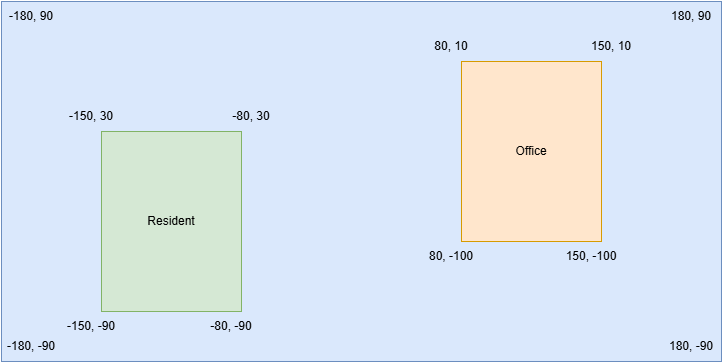

In [ ]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [ ]:
import pandas as pd
from radp_library import get_ue_data, plot_ue_tracks

In [ ]:
params = {
    "ue_tracks_generation": {
            "params": {
                "simulation_duration": 3600,
                "simulation_time_interval_seconds": 0.01,
                "num_ticks": 50,
                "num_batches": 1,
                "ue_class_distribution": {
                    "stationary": {
                        "count": 10,
                        "velocity": 0,
                        "velocity_variance": 1
                    },
                    "pedestrian": {
                        "count": 5,
                        "velocity": 2,
                        "velocity_variance": 1
                    },
                    "cyclist": {
                        "count": 5,
                        "velocity": 5,
                        "velocity_variance": 1
                    },
                    "car": {
                        "count": 12,
                        "velocity": 20,
                        "velocity_variance": 1
                    }
                },
                "lat_lon_boundaries": {
                    "min_lat": -90,
                    "max_lat": 90,
                    "min_lon": -180,
                    "max_lon": 180
                },
                "gauss_markov_params": {
                    "alpha": 0.5,
                    "variance": 0.8,
                    "rng_seed": 42,
                    "lon_x_dims": 100,
                    "lon_y_dims": 100,
                    "// TODO": "Account for supporting the user choosing the anchor_loc and cov_around_anchor.",
                    "// Current implementation": "the UE Tracks generator will not be using these values.",
                    "// anchor_loc": {},
                    "// cov_around_anchor": {}
            }
        }
    }
}

#### resident area ue generation
- ue(s) remain inside in resident area say for tick 0-9 [area coordinates, tick range → hyper parameters]

In [ ]:
resident_params = params.copy()
resident_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
resident_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
resident_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": -120,
    "max_lat": 30,
    "min_lon": -150,
    "max_lon": -80
}

In [ ]:
resident_0_9 = get_ue_data(resident_params)

print(resident_0_9.shape)
print(resident_0_9['mock_ue_id'].nunique())
print(resident_0_9['tick'].nunique())

print(resident_0_9['mock_ue_id'].unique())
print(resident_0_9['tick'].unique())

resident_0_9.head()

In [ ]:
plot_ue_tracks(resident_0_9)

In [ ]:
resident_0_9[['lon', 'lat', 'tick']].describe()

# ? what about the ue_class_distribution? this controls number of UE for each class and their velocity.
# ? what about the gauss_markov_params?
# ? In future how to incorporate the footfall data into the UE data?
# ? Using the get_ue_data function, how to map ue_id(s) as they always start from 0, just like ticks.
# TODO: for next area (office), need to update the ticks to make it 10-19.
# TODO: check for seed control, needed for introducing the probabilistic feature, otherwise the same data will be generated each time

#### ue_id, tick sequencing

In [ ]:
from radp.digital_twin.mobility.ue_tracks import UETracksGenerator
from radp.digital_twin.mobility.ue_tracks_params import UETracksGenerationParams
from radp.common import constants

In [ ]:
def get_ue_data2(params: dict, start_id: int = 0, tick_start: int = 0) -> pd.DataFrame:
    """
    Generates user equipment (UE) tracks data using specified simulation parameters.

    This function initializes a UETracksGenerationParams object using the provided parameters
    and then iterates over batches generated by the UETracksGenerator. Each batch of UE tracks
    data is consolidated into a single DataFrame which captures mobility tracks across multiple
    ticks and batches, as per the defined parameters.

    The UE tracks are returned in form of a dataframe with mock_ue_id starting from `start_id`.

    Parameters:
        - params (dict): Dictionary of simulation parameters.
        - start_id (int): The starting UE ID for the generated data. Default is 0.

    Returns:
        - pd.DataFrame: DataFrame containing UE tracks, with columns mock_ue_id, lon, lat, tick.
    """
    
    # Initialize the UE data
    ue_tracks_params = UETracksGenerationParams(params)

    ue_tracks_generation = pd.DataFrame()  # Initialize an empty DataFrame
    for ue_tracks_generation_batch in UETracksGenerator.generate_as_lon_lat_points(
        rng_seed=ue_tracks_params.rng_seed,
        lon_x_dims=ue_tracks_params.lon_x_dims,
        lon_y_dims=ue_tracks_params.lon_y_dims,
        num_ticks=ue_tracks_params.num_ticks,
        num_UEs=ue_tracks_params.num_UEs,
        num_batches=ue_tracks_params.num_batches,
        alpha=ue_tracks_params.alpha,
        variance=ue_tracks_params.variance,
        min_lat=ue_tracks_params.min_lat,
        max_lat=ue_tracks_params.max_lat,
        min_lon=ue_tracks_params.min_lon,
        max_lon=ue_tracks_params.max_lon,
        mobility_class_distribution=ue_tracks_params.mobility_class_distribution,
        mobility_class_velocities=ue_tracks_params.mobility_class_velocities,
        mobility_class_velocity_variances=ue_tracks_params.mobility_class_velocity_variances,
    ):
        # Modify the mock_ue_id to start from start_id
        ue_tracks_generation_batch[constants.MOCK_UE_ID] += start_id
        
        # Modify the tick values to start from tick_start
        ue_tracks_generation_batch["tick"] += tick_start        
        
        # Append each batch to the main DataFrame
        ue_tracks_generation = pd.concat([ue_tracks_generation, ue_tracks_generation_batch], ignore_index=True)

    return ue_tracks_generation


In [ ]:
starting_ue_tick = {
    'start_id' : 100,
    'tick_start' : 10
}
data2 = get_ue_data2(params, **starting_ue_tick)

In [ ]:
data2

In [ ]:
data2[['mock_ue_id', 'tick']].describe()

#### office area ue generation

In [ ]:
office_params = params.copy()
office_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
office_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
office_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": -100,
    "max_lat": 10,
    "min_lon": 80,
    "max_lon": 150
}

In [ ]:
starting_ue_tick = {
    'start_id' : 32,
    'tick_start' : 10
}

office_0_9 = get_ue_data2(office_params, **starting_ue_tick)

print(office_0_9.shape)
print(office_0_9['mock_ue_id'].nunique())
print(office_0_9['tick'].nunique())

print(office_0_9['mock_ue_id'].unique())
print(office_0_9['tick'].unique())

office_0_9.head()

In [ ]:
plot_ue_tracks(office_0_9)

#### initial city data

In [ ]:
combined_df = pd.concat([resident_0_9, office_0_9], ignore_index=True)
print(combined_df.shape)
combined_df.head()

In [ ]:
plot_ue_tracks(combined_df)

### Component generator

In [ ]:
import random, math

def generate_components(num_components=5, min_size=5, max_size=20, min_lat_bound=-90, max_lat_bound=90, min_lon_bound=-180, max_lon_bound=180, seed=None):
    """
    Generate non-overlapping rectangular components with latitude and longitude bounds.

    Parameters:
    - num_components (int): Number of components/areas to generate.
    - min_size (float): Minimum size of the component (in degrees). Dictates the width and height of the component.
    - max_size (float): Maximum size of the component (in degrees). Dictates the width and height of the component.
    - min_lat_bound (float): Minimum latitude boundary for component placement.
    - max_lat_bound (float): Maximum latitude boundary for component placement.
    - min_lon_bound (float): Minimum longitude boundary for component placement.
    - max_lon_bound (float): Maximum longitude boundary for component placement.
    - seed (int, optional): Random seed for reproducibility.

    Returns:
    - list: A list of dictionaries, each containing:
        - component_id (int): Unique identifier for the component.
        - bounds (tuple): Latitude and longitude bounds of the component (min_lat, max_lat, min_lon, max_lon).
        - area (float): Area of the component in square kilometers, approximately.
    """
    if seed is not None:
        random.seed(seed)
    
    components = []
    used_areas = []  # Stores placed areas to check overlap
    
    for i in range(num_components):
        while True:
            # Generate random size within constraints
            width = random.uniform(min_size, max_size)
            height = random.uniform(min_size, max_size)
            
            # Generate random bottom-left corner
            min_lat = random.uniform(min_lat_bound, max_lat_bound - height)
            min_lon = random.uniform(min_lon_bound, max_lon_bound - width)
            
            # Compute top-right corner
            max_lat = min_lat + height
            max_lon = min_lon + width
            
            new_area = (min_lat, max_lat, min_lon, max_lon)
            
            # overlap check
            if any(
                not (new_area[1] <= old[0] or new_area[0] >= old[1] or
                     new_area[3] <= old[2] or new_area[2] >= old[3])  
                for old in used_areas
            ):
                continue  # Retry if overlapping
            
            # Store area and assign component
            used_areas.append(new_area)
            
            # Calculate area in km^2
            lat_km_per_degree = 111  # Approximate conversion factor
            lon_km_per_degree = 111 * abs(math.cos(math.radians((min_lat + max_lat) / 2)))  # Varies with latitude
            area = width * lon_km_per_degree * height * lat_km_per_degree
            
            components.append({
                "component_id": i + 1,
                "bounds": new_area,  # (min_lat, max_lat, min_lon, max_lon)
                "area": round(area, 2)
            })
            break
    
    return components



In [ ]:
components = generate_components()
for comp in components:
    print(comp)

**note**: the areas are humungous. need to work with `min_size` and `max_size`

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_components(components):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Set map limits (world map projection)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    
    # Draw a world map grid
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Generated Component Areas")

    # Plot each component as a rectangle
    for idx, component in enumerate(components):
        min_lat, max_lat, min_lon, max_lon = component['bounds']
        width = max_lon - min_lon
        height = max_lat - min_lat

        rect = patches.Rectangle(
            (min_lon, min_lat), width, height, 
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(min_lon + width / 2, min_lat + height / 2, f"{idx+1}", fontsize=10, ha='center', va='center')

    plt.show()


In [ ]:
plot_components(components)

In [ ]:
# generate + plot

def gen_plot(num_components, min_size, max_size):
    components = generate_components(num_components, min_size, max_size)
    plot_components(components)
    
    return components

In [ ]:
comp_params = {
    "num_components": 4,
    "min_size": 10,
    "max_size": 50
}

components = gen_plot(**comp_params)

In [ ]:
components = gen_plot(**comp_params)

In [ ]:
components = gen_plot(**comp_params)

#### 2 areas trial

In [ ]:
comp_params = {
    "num_components": 2,
    "min_size": 10,
    "max_size": 50
}

components = gen_plot(**comp_params)

In [ ]:
components

In [ ]:
min_lat, max_lat, min_lon, max_lon = components[0]['bounds']

office_params = params.copy()
office_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
office_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
office_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": min_lat,
    "max_lat": max_lat,
    "min_lon": min_lon,
    "max_lon": max_lon,
}

In [ ]:
office_1 = get_ue_data2(office_params)

office_1

In [ ]:
min_lat, max_lat, min_lon, max_lon = components[1]['bounds']

resident_params = params.copy()
resident_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
resident_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
resident_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": min_lat,
    "max_lat": max_lat,
    "min_lon": min_lon,
    "max_lon": max_lon,
}

In [ ]:
starting_ue_tick = {
    'start_id' : 32,
    'tick_start' : 10
}

resident_1 = get_ue_data2(resident_params, **starting_ue_tick)

resident_1

In [ ]:
merged_df = pd.concat([office_1, resident_1], ignore_index=True)
print(merged_df.shape)
merged_df.head()

In [ ]:
plot_ue_tracks(merged_df)

## incorporate rx power func

inside `_radp_model_rftwin` func incorporate `_calculate_received_power` func. 

here, just looking at the output of immediate functions and how the incorporation is changing rx power values

In [ ]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [ ]:
from radp.digital_twin.traffic_load_model.city_dt_gen import city_digitaltwin_generator

In [ ]:
root_dir = Path().absolute().parent

In [ ]:
import json
import pandas as pd

# --- Load data ---

# * site_config.csv, time_params.json, spatial_params.json should be added inside the notebooks/data/sim_data/tl_data/ folder beforehand.

site_config_rel_path = Path("notebooks/data/sim_data/tl_data/site_config.csv")
spatial_params_rel_path = Path("notebooks/data/sim_data/tl_data/spatial_params.json")
time_params_rel_path = Path("notebooks/data/sim_data/tl_data/time_params.json")

site_config_path = root_dir / site_config_rel_path
spatial_params_path = root_dir / spatial_params_rel_path
time_params_path = root_dir / time_params_rel_path

site_config_data = pd.read_csv(site_config_path)
with open(spatial_params_path, "r") as f:
    spatial_params = json.load(f)
with open(time_params_path, "r") as f:
    time_params = json.load(f)

In [ ]:
site_config_data.head()

In [ ]:
site_config_data['cell_id'].nunique()

In [ ]:
spatial_params

In [ ]:
time_params

In [ ]:
total_ue = 500
trafficload_ue_data = city_digitaltwin_generator(total_ue, spatial_params, time_params, site_config_data)

In [ ]:
trafficload_ue_data.head()

In [ ]:
trafficload_ue_data.nunique()

In [ ]:
from radp.digital_twin.traffic_load_model.traffic_load_model import run_tl_simulation, _radp_model_rftwin

In [ ]:
ue_rxpower_data = _radp_model_rftwin(
    trafficload_ue_data,
    site_config_data
)

In [ ]:
ue_rxpower_data.head()

## traffic ue data + cco

flow note

1. generate traffic ue data using tl model code base
2. while at it, use cell topology from `data/` of cco
3. save the ue data
4. get cco score for given config
5. optimize the config using `dgpco_cco` algo, save the latest cco and config values. this can be compared with 4.

### generating ue data using cco example topology data

In [ ]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [ ]:
from radp.digital_twin.traffic_load_model.city_dt_gen import city_digitaltwin_generator

In [ ]:
root_dir = Path().absolute().parent

In [ ]:
import json
import pandas as pd

# --- Load data ---

# * site_config.csv, time_params.json, spatial_params.json should be added inside the notebooks/data/sim_data/tl_data/ folder beforehand.

site_config_rel_path = Path("notebooks/data/sim_data/tl_data/site_config.csv")
spatial_params_rel_path = Path("notebooks/data/sim_data/tl_data/spatial_params.json")
time_params_rel_path = Path("notebooks/data/sim_data/tl_data/time_params.json")
topology_rel_path = Path("notebooks/data/sim_data/tl_data/topology.csv") # copied from apps/cco/data/

site_config_path = root_dir / site_config_rel_path
spatial_params_path = root_dir / spatial_params_rel_path
time_params_path = root_dir / time_params_rel_path
topology_path = root_dir / topology_rel_path

site_config_data = pd.read_csv(site_config_path)
topology_data = pd.read_csv(topology_path)

with open(spatial_params_path, "r") as f:
    spatial_params = json.load(f)
with open(time_params_path, "r") as f:
    time_params = json.load(f)

In [ ]:
topology_data.head()

In [ ]:
topology_data['cell_id'].nunique()

In [ ]:
topology_data[['cell_lat', 'cell_lon']].nunique()

In [ ]:
topology_data[['cell_lat', 'cell_lon']].describe()

In [ ]:
total_ue = 500
trafficload_ue_data = city_digitaltwin_generator(total_ue, spatial_params, time_params, topology_data)

In [ ]:
trafficload_ue_data.head()

In [ ]:
trafficload_ue_data.shape

In [ ]:
trafficload_ue_data.nunique()

### get cco values for generated traffic ue

- generate 0-23 ticks traffic ue. (24hrs)
- use 0-22 ticks for training. merge if needed into single csv. >>> training ue
- 24th ue data >>> prediction ue
- get cco for prediction ue

In [ ]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [ ]:
import pandas as pd

# --- Load data ---

# * ue_data/ should be added inside the notebooks/data/sim_data/tl_data/ folder beforehand.

root_dir = Path().absolute().parent
ue_rel_path = Path("notebooks/data/sim_data/tl_data/ue_data")

ue_path = root_dir / ue_rel_path

# Read all 24 CSV files into a single DataFrame
ue_data_files = ue_path.glob("*.csv")
ue_data = pd.concat([pd.read_csv(file) for file in ue_data_files], ignore_index=True)
ue_data.sort_values(by="tick", inplace=True)
ue_data.shape

In [ ]:
ue_data['tick'].unique()

In [ ]:
# Split the data based on the tick column
training_data = ue_data[ue_data['tick'] < 23]
prediction_data = ue_data[ue_data['tick'] == 23]

# Display the shapes of the resulting datasets
print(f"Training Data Shape: {training_data.shape}")
print(f"Prediction Data Shape: {prediction_data.shape}")

In [ ]:
# saving training and prediction data to csv files
train_test_dir = Path("tl_train_test_data")
(ue_path.parent / train_test_dir).mkdir(exist_ok=True)

training_data.to_csv(ue_path.parent / train_test_dir / "ue_training_data.csv", index=False)
prediction_data.to_csv(ue_path.parent / train_test_dir / "ue_data.csv", index=False)